In [10]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns 
from scipy.stats import linregress
import os

In [11]:
df = pd.read_csv("/data/Supplemental_Tables/Supplemental Table 2.csv", header=[0, 1], skipinitialspace=True, index_col = 0)

In [21]:
df

percent AT8 positive area           percent pTDP43 positive area  \
                                 CaH       MTG                          CaH   
H19.33.004                  0.000001  0.017713                     0.000074   
H20.33.001                  0.066747  0.053115                     0.000451   
H20.33.005                  0.004159  0.113147                     0.000328   
H20.33.008                  0.558316  1.419477                     0.000372   
H20.33.011                  0.282541  0.903203                     0.000012   
H20.33.012                  0.001723  0.118152                     0.000048   
H20.33.013                  0.013461  0.048466                     0.000060   
H20.33.015                  0.015323  0.127550                     0.000023   
H20.33.016                  0.008250  0.076824                     0.000081   
H20.33.017                  4.135247  1.978833                     0.000130   
H20.33.018                  3.432789  2.011316                     0.000012   
H20.33.019                  0.000251  0.043413                     0.000064   
H20.33.020                  1.717248  1.395572                     0.000044   
H20.33.025                  0.081498  0.592027                     0.000094   
H20.33.026                  1.929459  1.011174                     0.000068   
H20.33.027                  0.012355  0.101751                     0.000105   
H20.33.028                  0.219539  1.683493                     0.000743   
H20.33.029                  0.058186  0.093844                     0.000465   
H20.33.031                  0.339731  1.605940                     0.000634   
H20.33.033                  0.741658  1.200099                     0.000750   
H20.33.036                  0.101791  0.214960                     0.000178   
H20.33.037                  0.039628  3.455456                     0.000651   
H20.33.039                  0.047158  0.274923                     0.000457   
H20.33.040                  0.058698  0.056064                     0.000903   
H20.33.046                  0.988699  1.666673                     0.000293   
H21.33.001                  0.007741  0.033161                     0.000322   
H21.33.002                  1.258064  2.588242                     0.000648   
H21.33.003                  0.003378  0.007572                     0.000111   
H21.33.004                  0.000208  0.015823                     0.000132   
H21.33.013                  0.072649  2.837022                     0.000151   
H21.33.018                  0.020185  0.007338                     0.000380   
H21.33.019                  0.005162  0.011863                     0.000503   
H21.33.022                  0.729804  0.711326                     0.000238   
H21.33.026                  0.022816  0.677142                     0.000127   
H21.33.027                  0.046773  0.650424                     0.000058   
H21.33.028                  0.008373  0.041367                     0.000037   
H21.33.032                  0.010074  0.060415                     0.000082   
H21.33.033                  0.191587  2.992554                     0.000508   
H21.33.035                  0.033705  1.242431                     0.000743   
H21.33.038                  0.013295  0.006604                     0.000563   
H21.33.039                  0.238411  4.201246                     0.000109   

                     percent 6e10 dense core plaque area            \
                 MTG                                 CaH       MTG   
H19.33.004  0.000000                            0.000802  0.001994   
H20.33.001  0.002635                            0.000000  0.013077   
H20.33.005  0.000000                            0.010122  0.044342   
H20.33.008  0.000000                            0.006540  0.429847   
H20.33.011  0.000000                            0.001428  0.122650   
H20.33.012  0.000000                            0.000000  0.006812   
H20.33.013  0.000000                            0.000

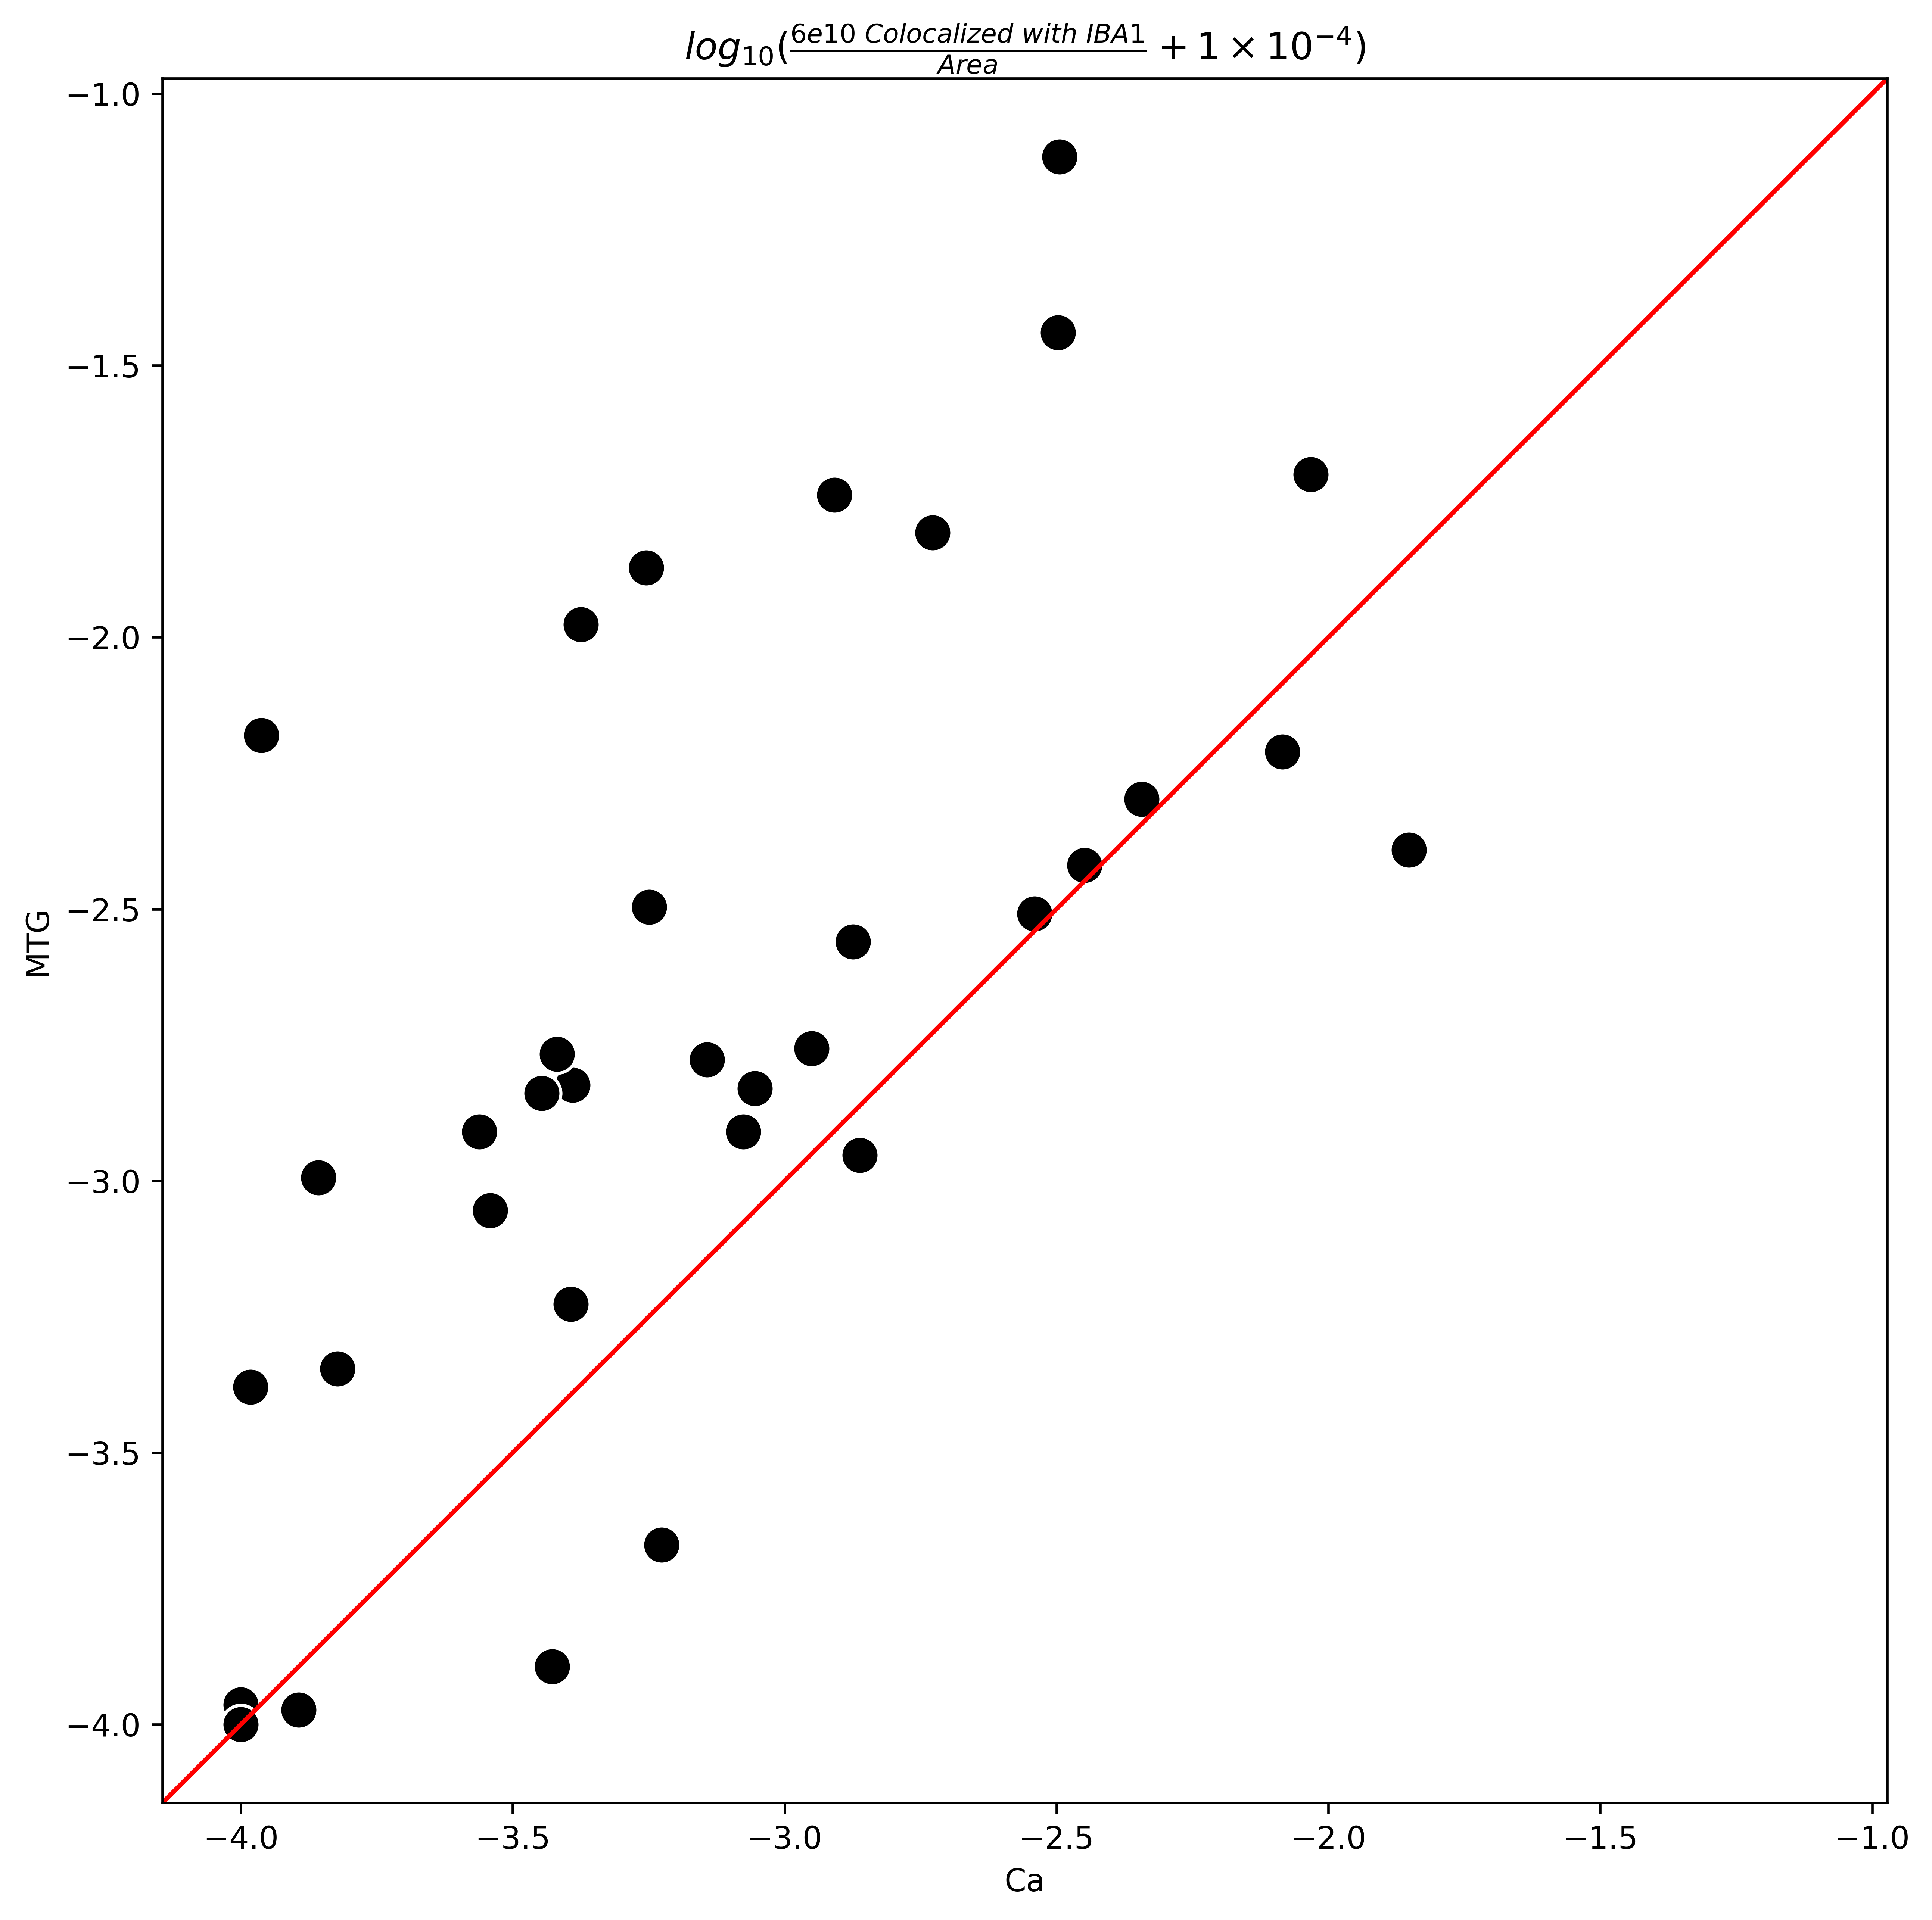

In [14]:
fig, ax = plt.subplots(figsize = (10, 10), dpi = 600)
for region in ["MTG"]:
    x = np.log10((df[("percent of 6e10 positive objects colocalized with Iba1 positive objects", "CaH")] * df[( "percent 6e10 positive area", "CaH")] / 1e4) + 1e-4)
    y  = np.log10((df[("percent of 6e10 positive objects colocalized with Iba1 positive objects", region)] * df[( "percent 6e10 positive area", region)] / 1e4) + 1e-4)
    sns.scatterplot( x = x,  y =  y, ax = ax, label = region, color = "black", legend = False, s = 150)
    
    plt.ylabel("MTG")
    plt.xlabel("Ca")
    plt.title(r"$log_{10}(\frac{6e10\ Colocalized\ with\ IBA1}{Area} + 1 \times 10^{-4})$")
    # plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title = f"$R^2$ = {r**2:.2f} \n p = {p:.5f} \n slope = {m:.2}")
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5),)
ax.set_aspect("equal", "box")
lims = ax.get_xlim() + ax.get_ylim()
plt.ylim(min(lims), max(lims))
plt.xlim(min(lims), max(lims))
plt.plot([min(lims), max(lims)],[min(lims), max(lims)], color = "red")
# fig.savefig(
#     './Figures/Figure5_Neuropath_Colocalization.svg',
#     bbox_inches='tight',
# )
plt.show()

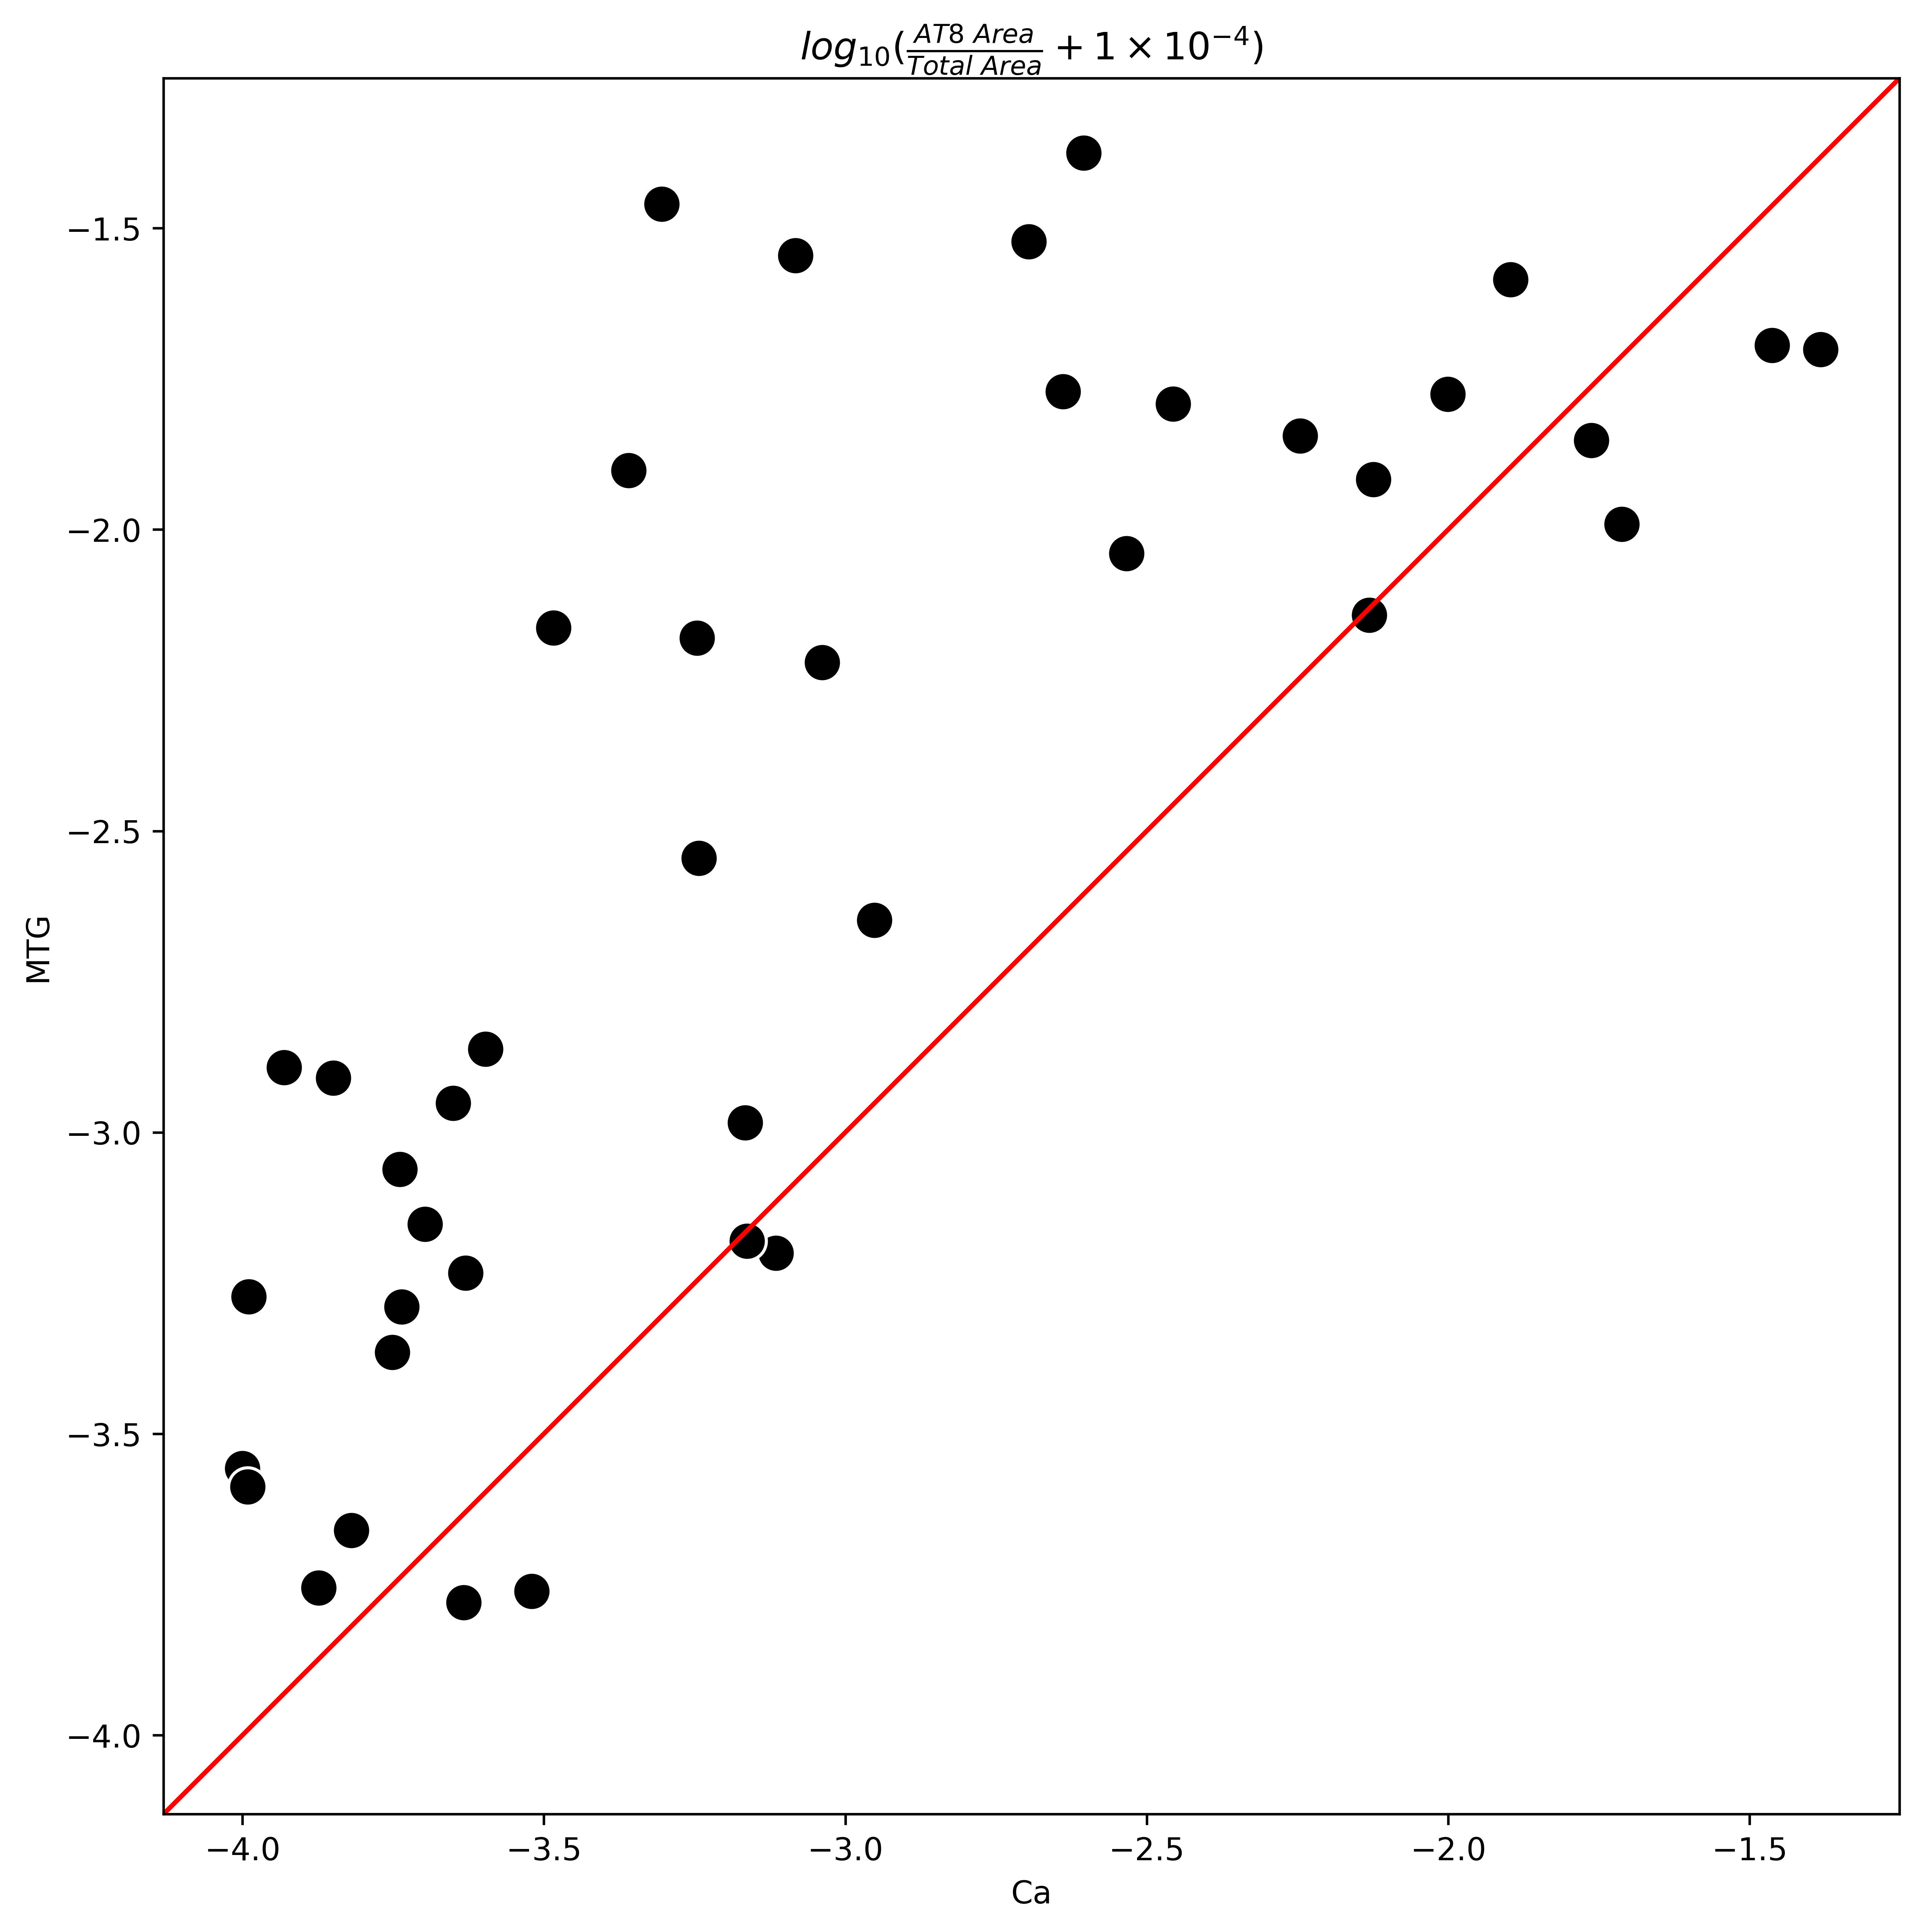

In [15]:
fig, ax = plt.subplots(figsize = (10, 10), dpi = 600)
feature = "percent AT8 positive area"
region = "MTG"
x = np.log10(df[(feature, "CaH")].values / 100 + 1e-4)
y  = np.log10(df[(feature, f"{region}")].values / 100 + 1e-4)
rel_idx = ~(np.isnan(x)) & ~(np.isnan(y))
x = x[rel_idx]
y = y[rel_idx]
m, b, r, p, _= linregress(x, y)
sns.scatterplot( x = x,  y =  y, ax = ax, s = 150, color = "black", legend = False)
plt.title(r"$log_{10}(\frac{AT8\ Area}{Total\ Area} + 1\times10^{-4})$")
plt.xlabel(f"Ca")
plt.ylabel(f"{region}")
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title = f"$R^2$ = {r**2:.2f} \n p = {p:.5f} \n slope = {m:.2}")
ax.set_aspect("equal", "box")
lims = ax.get_xlim() + ax.get_ylim()
plt.ylim(min(lims), max(lims))
plt.xlim(min(lims), max(lims))
plt.plot([min(lims), max(lims)], [min(lims), max(lims)], color = "red")
# fig.savefig(
#     './Figures/Figure2_AT8_Area.svg',
#     bbox_inches='tight',
# )
plt.show()

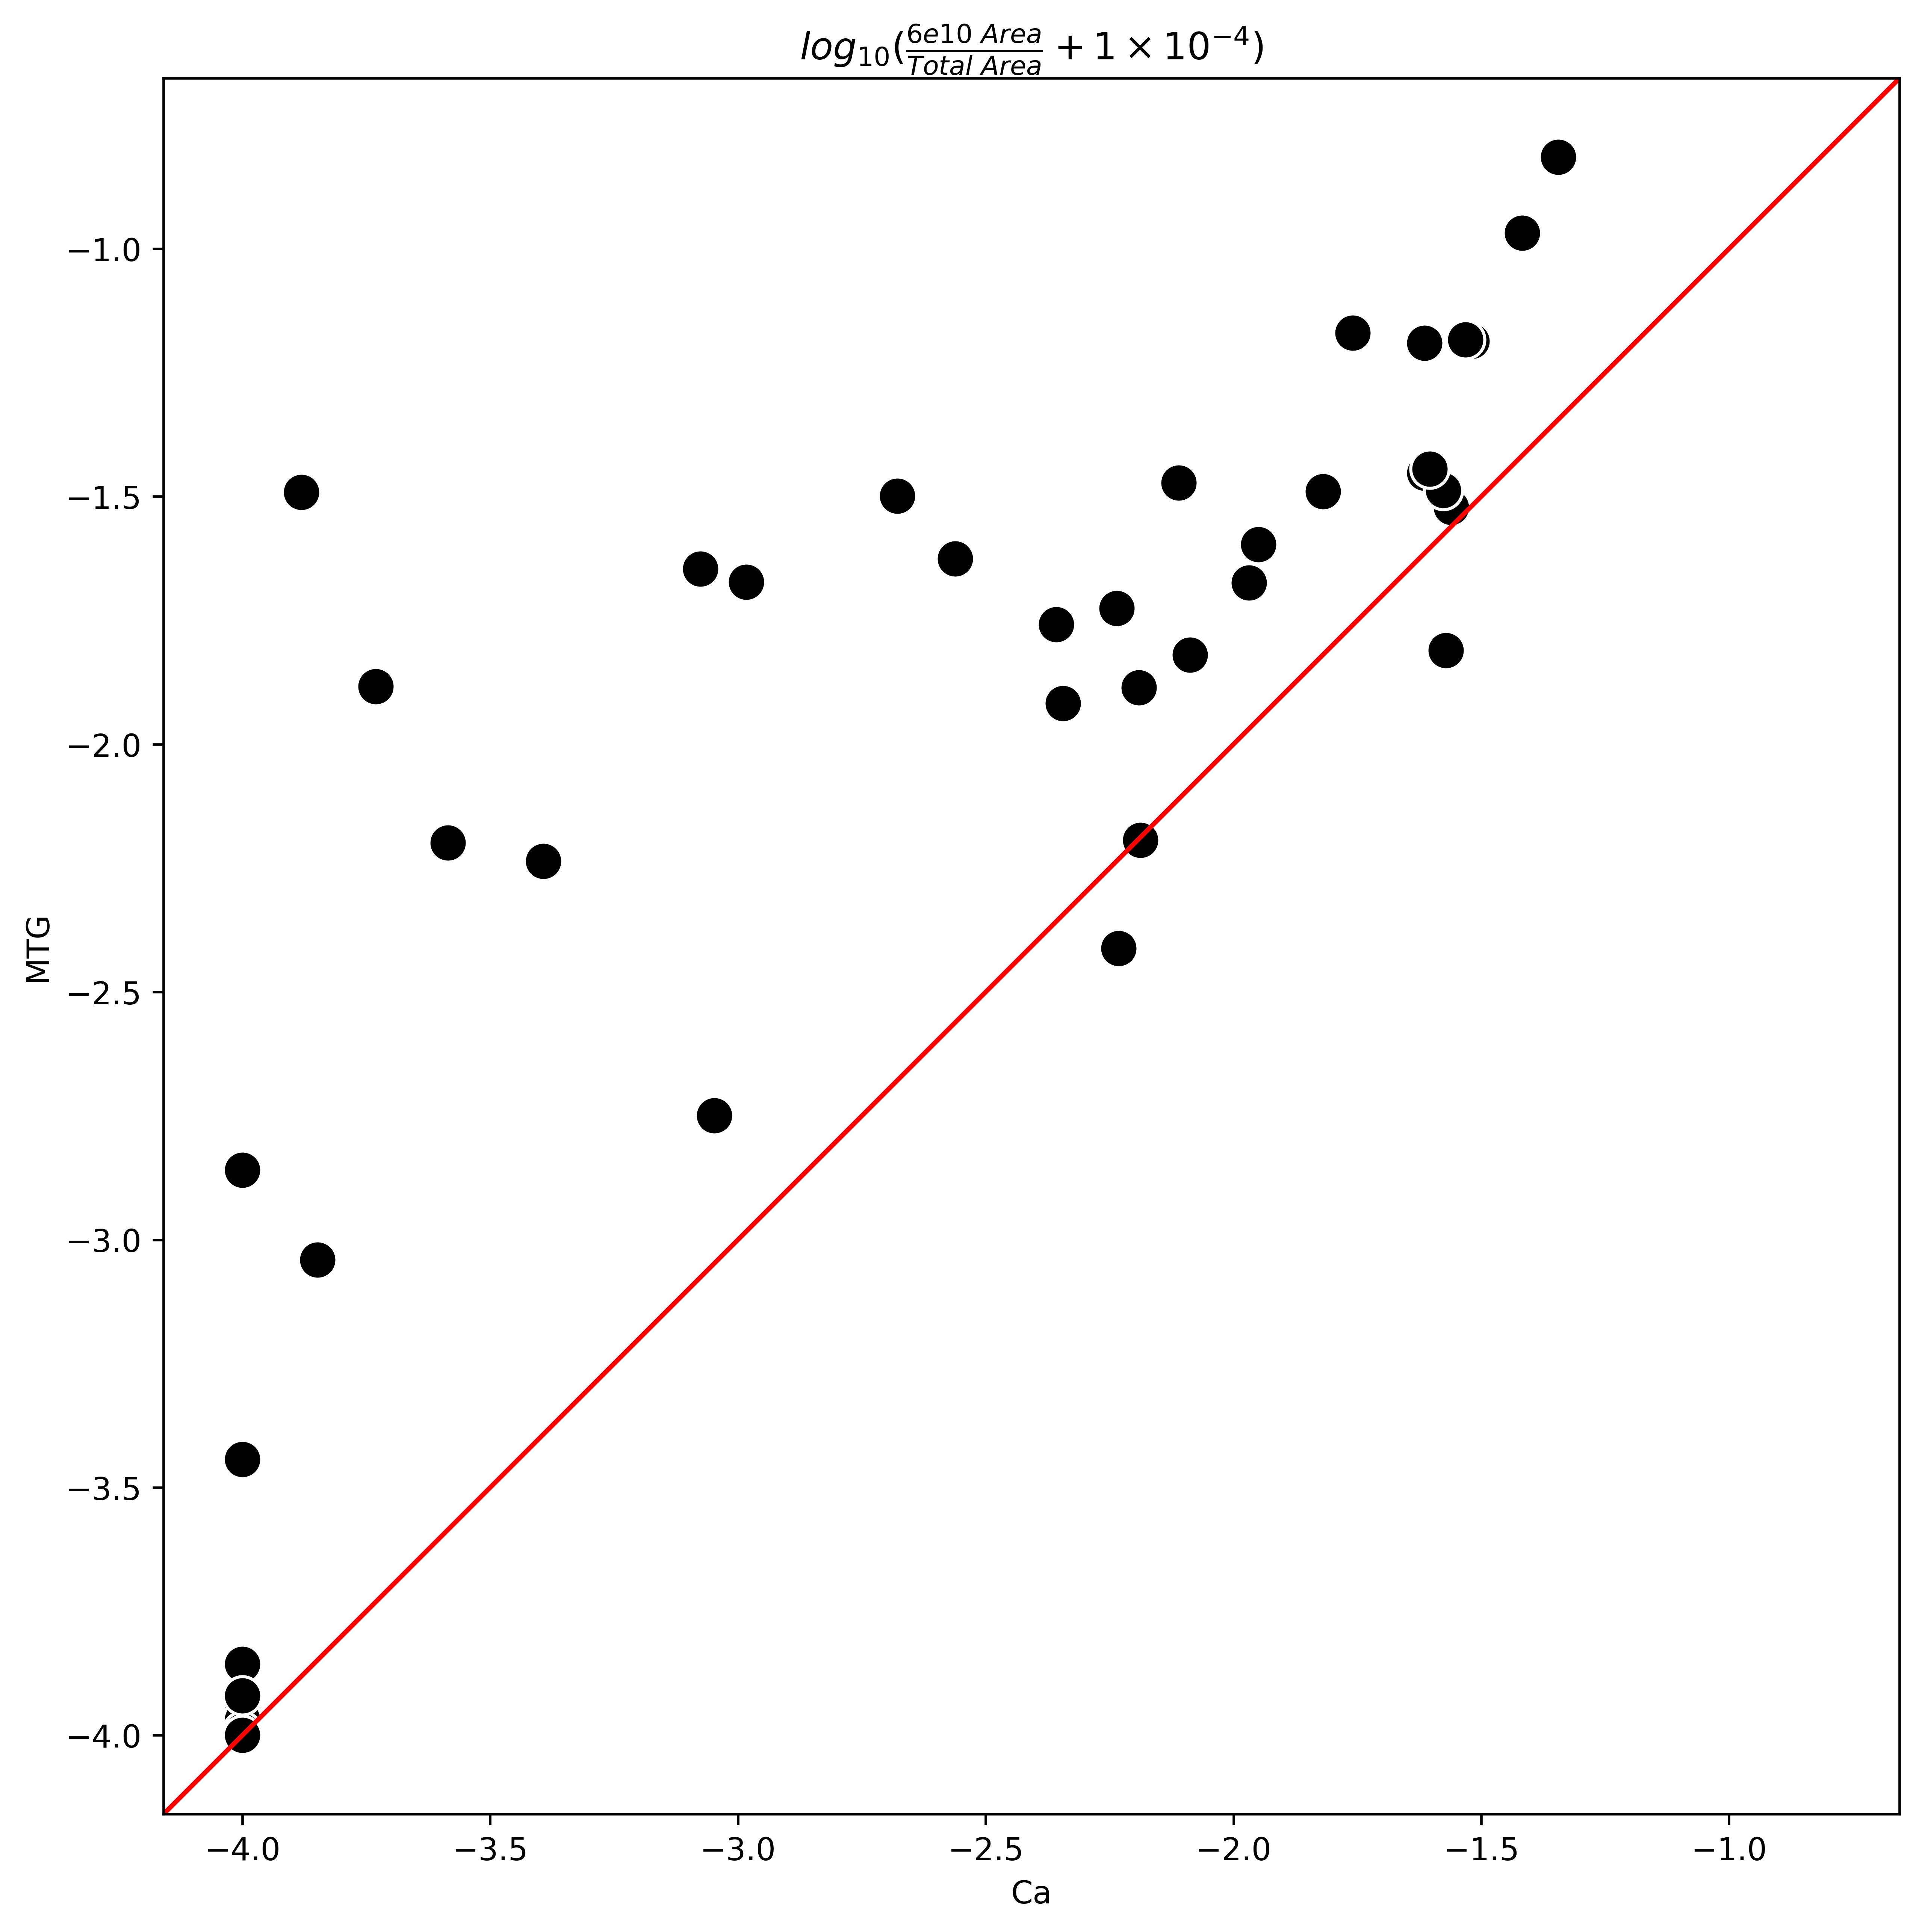

In [16]:
fig, ax = plt.subplots(figsize = (10, 10), dpi = 600)
feature = "percent 6e10 positive area"
region = "MTG"
x = np.log10(df[(feature, "CaH")].values / 100 + 1e-4)
y  = np.log10(df[(feature, f"{region}")].values / 100 + 1e-4)
rel_idx = ~(np.isnan(x)) & ~(np.isnan(y))
x = x[rel_idx]
y = y[rel_idx]
m, b, r, p, _= linregress(x, y)
sns.scatterplot( x = x,  y =  y, ax = ax, s = 150, color = "black", legend = False)
plt.title(r"$log_{10}(\frac{6e10\ Area}{Total\ Area} + 1\times10^{-4})$")
plt.xlabel(f"Ca")
plt.ylabel(f"{region}")
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title = f"$R^2$ = {r**2:.2f} \n p = {p:.5f} \n slope = {m:.2}")
ax.set_aspect("equal", "box")
lims = ax.get_xlim() + ax.get_ylim()
plt.ylim(min(lims), max(lims))
plt.xlim(min(lims), max(lims))
plt.plot([min(lims), max(lims)], [min(lims), max(lims)], color = "red")
plt.show()

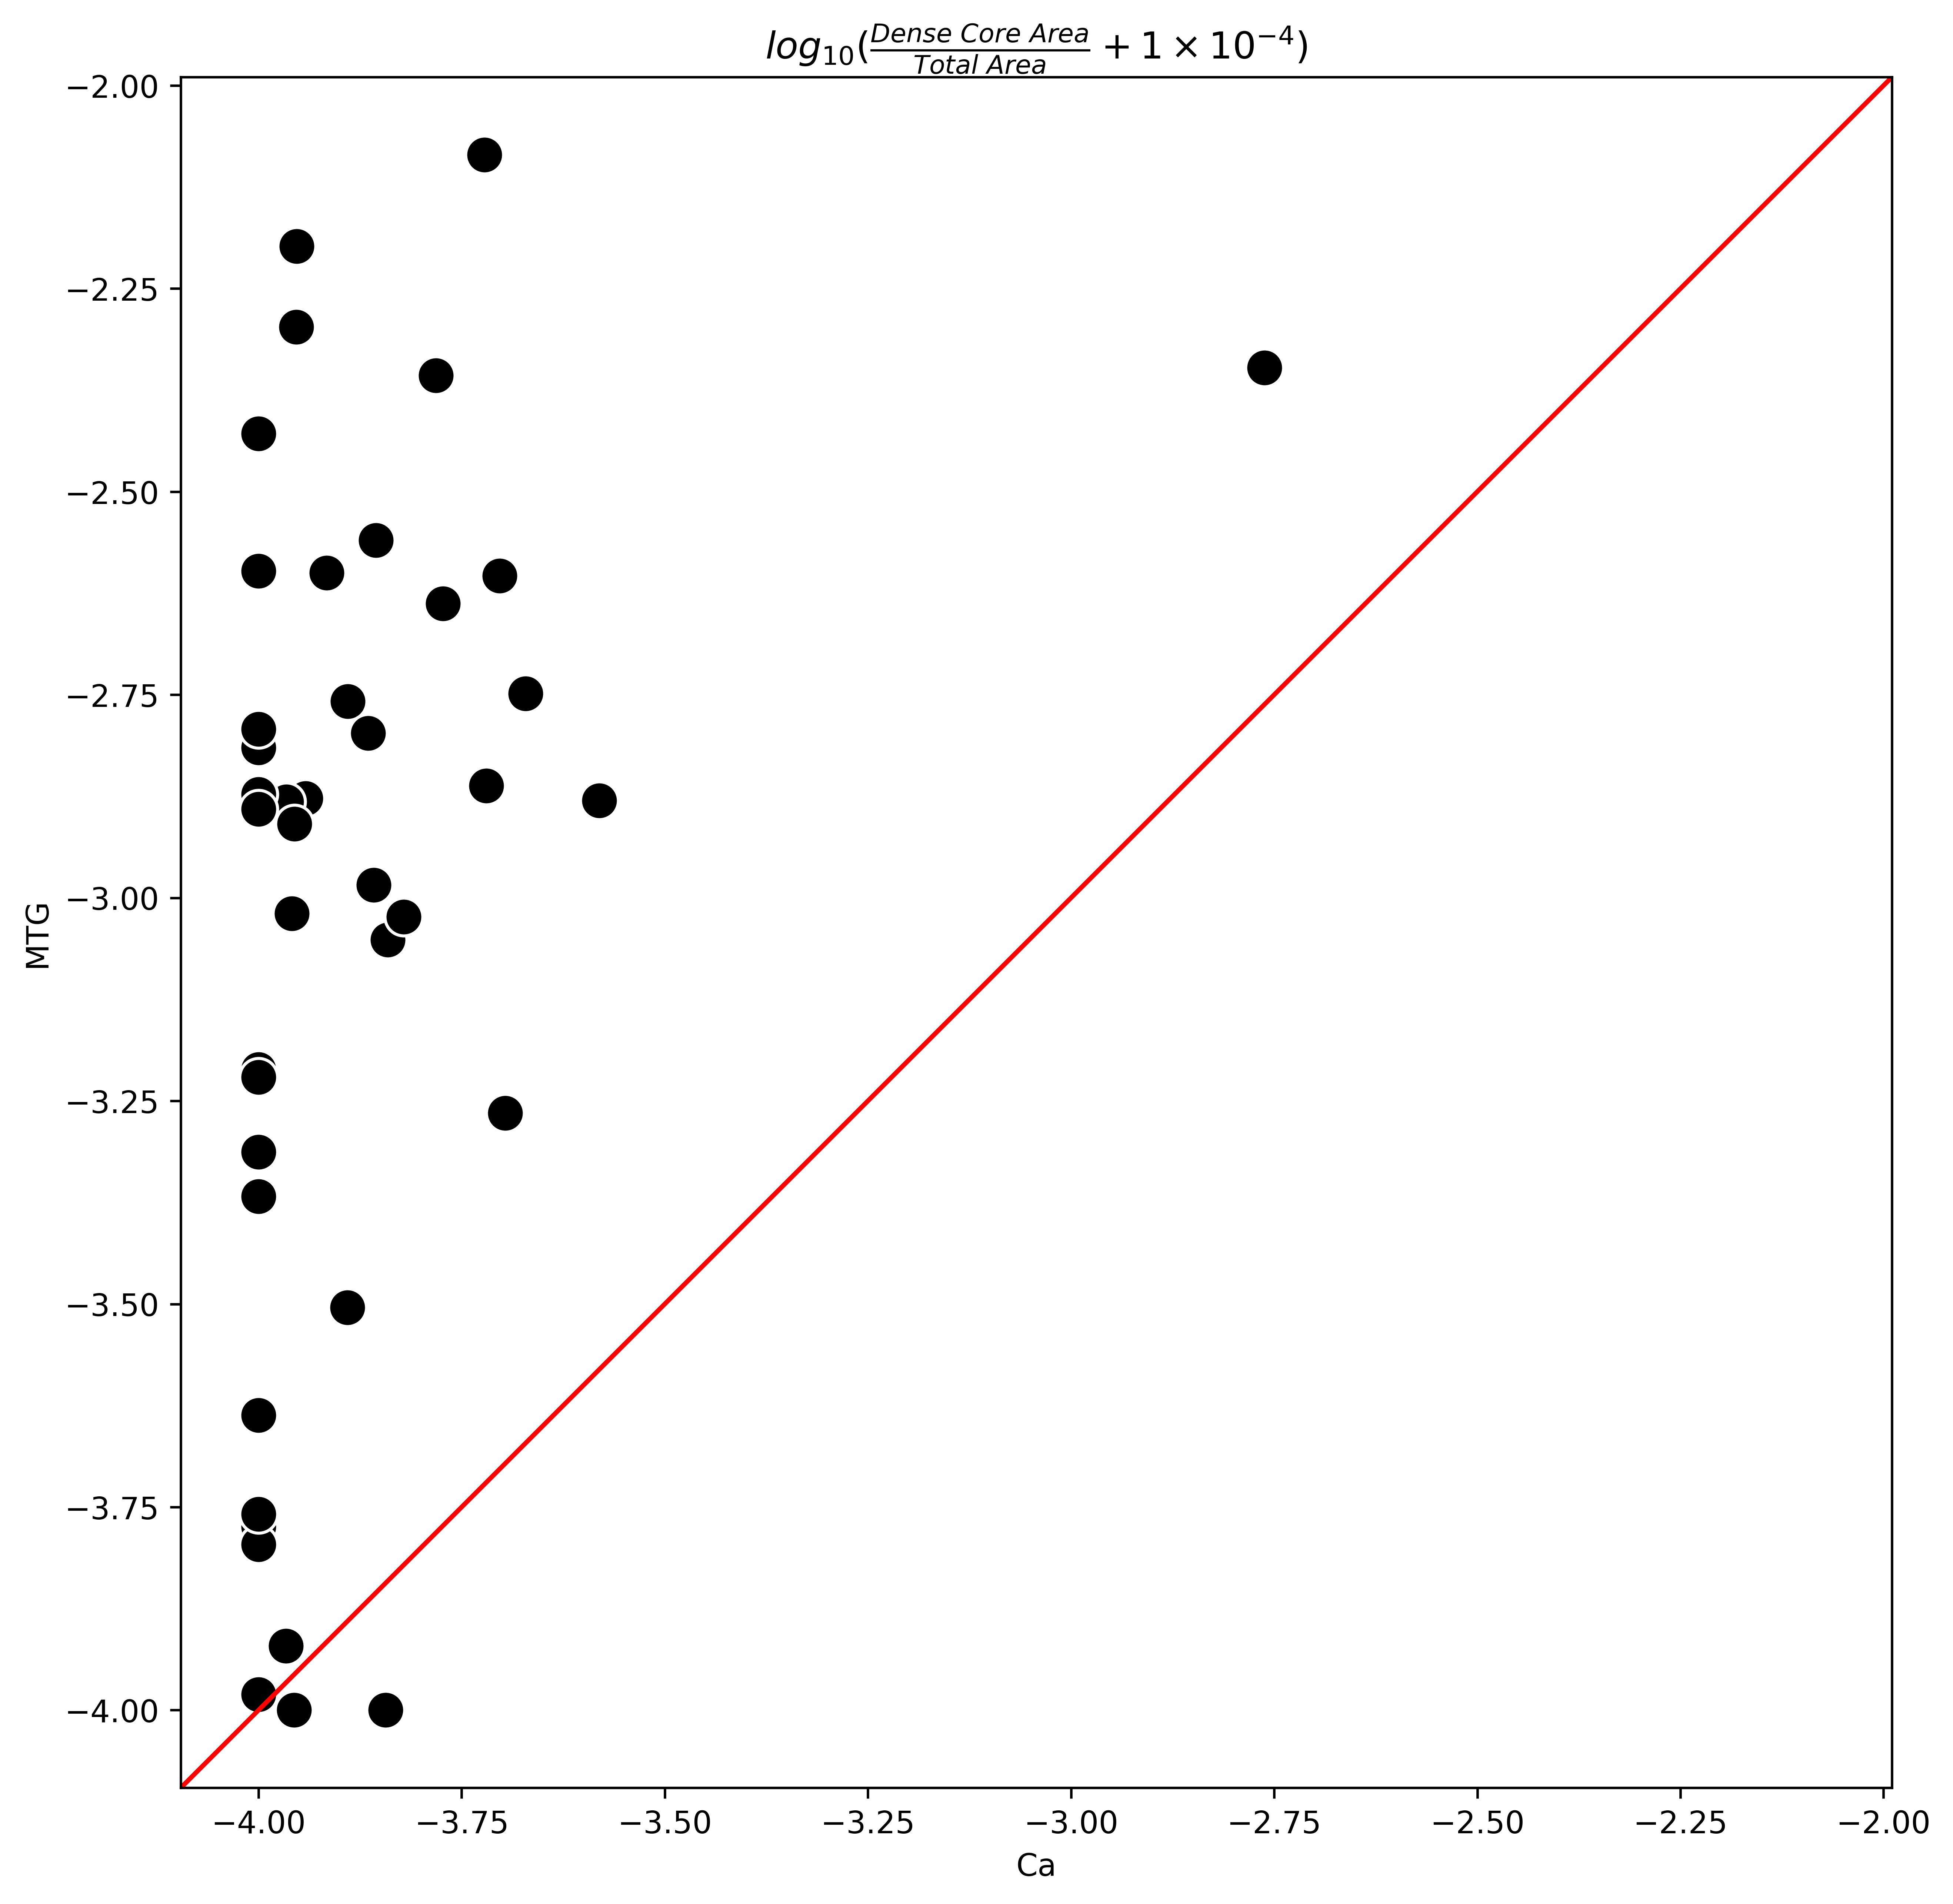

In [17]:
fig, ax = plt.subplots(figsize = (10, 10), dpi = 600)
feature = "percent 6e10 dense core plaque area"
region = "MTG"
x = np.log10(df[(feature, "CaH")].values / 100 + 1e-4)
y  = np.log10(df[(feature, f"{region}")].values / 100 + 1e-4)
rel_idx = ~(np.isnan(x)) & ~(np.isnan(y))
x = x[rel_idx]
y = y[rel_idx]
m, b, r, p, _= linregress(x, y)
sns.scatterplot( x = x,  y =  y, ax = ax, s= 150, color = "black", legend = False)
plt.title(r"$log_{10}(\frac{Dense\ Core\ Area}{Total\ Area} + 1\times10^{-4})$")
plt.xlabel(f"Ca")
plt.ylabel(f"{region}")
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title = f"$R^2$ = {r**2:.2f} \n p = {p:.5f} \n slope = {m:.2}")
ax.set_aspect("equal", "box")
lims = ax.get_xlim() + ax.get_ylim()
plt.ylim(min(lims), max(lims))
plt.xlim(min(lims), max(lims))
plt.plot([min(lims), max(lims)], [min(lims), max(lims)], color = "red")
# fig.savefig(
#     './Figures/Figure2_Dense_Core_Area.svg',
#     bbox_inches='tight',
# )
plt.show()

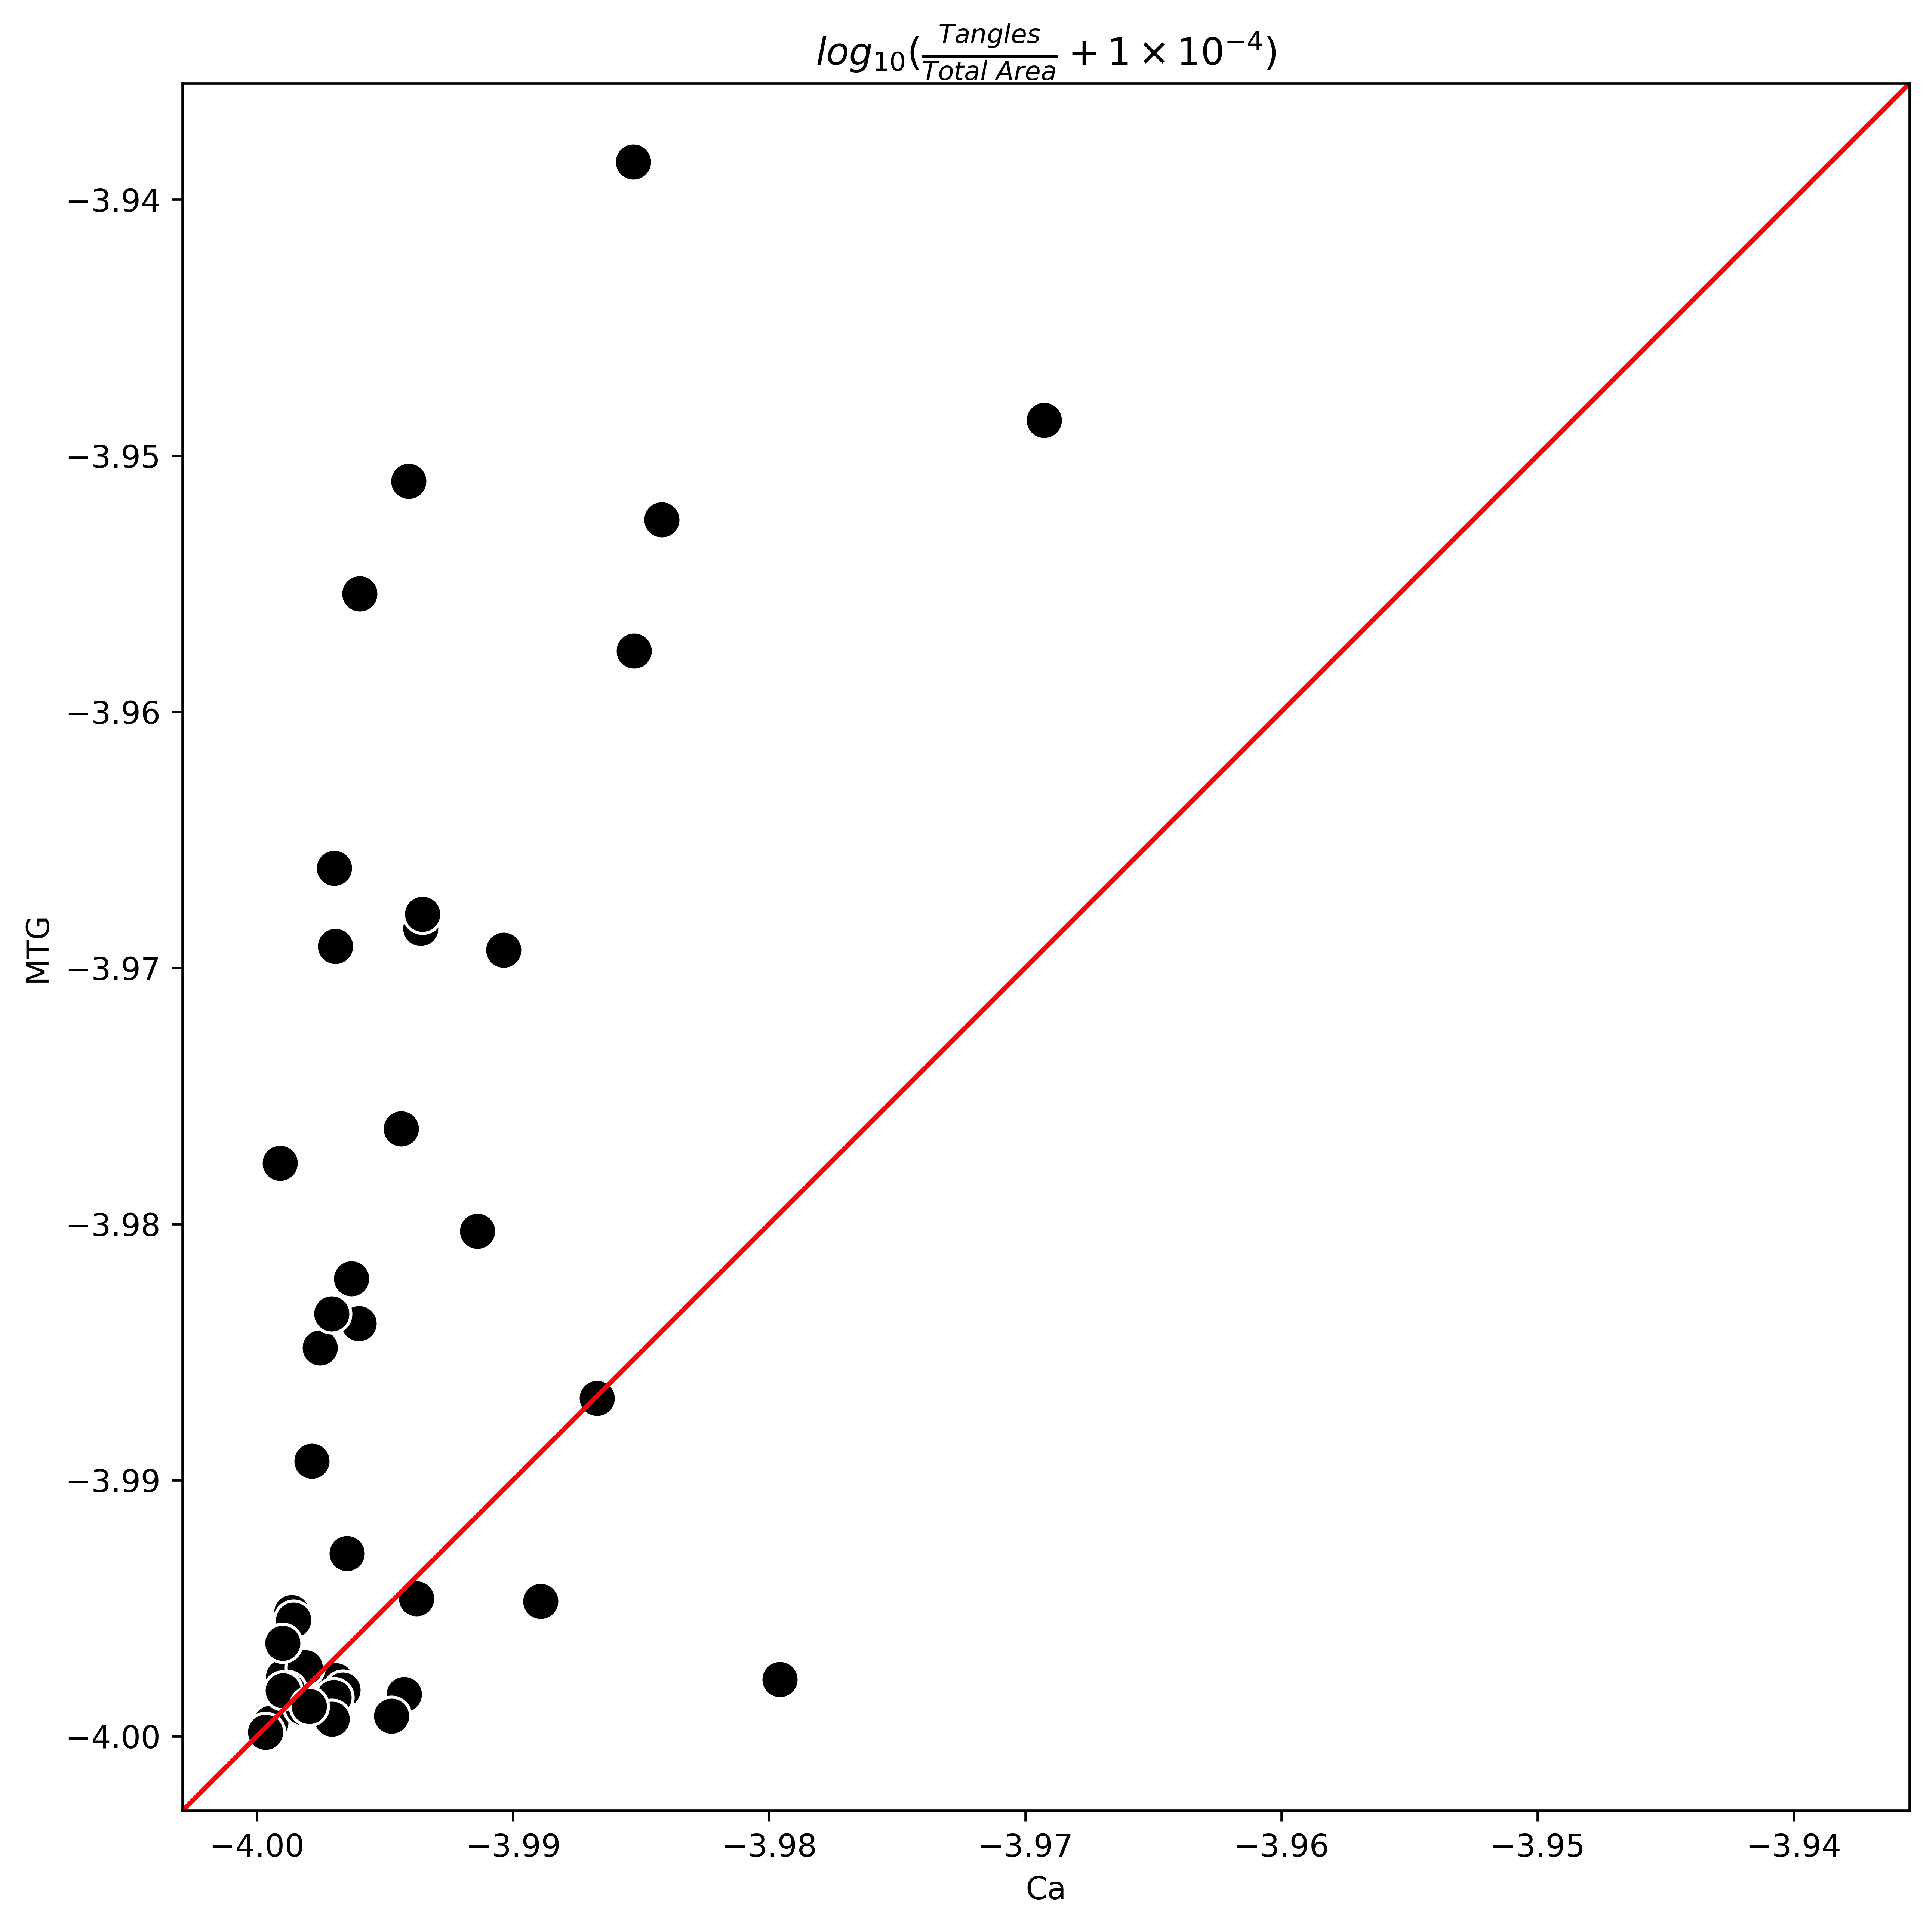

In [28]:
fig, ax = plt.subplots(figsize = (10, 10), dpi = 600)
feature = "tangle_per_tissue_area_um^2"
region = "MTG"
x = np.log10(df[(feature, "CaH")].values + 1e-4)
y  = np.log10(df[(feature, f"{region}")].values + 1e-4)
rel_idx = ~(np.isnan(x)) & ~(np.isnan(y))
x = x[rel_idx]
y = y[rel_idx]
m, b, r, p, _= linregress(x, y)
sns.scatterplot( x = x,  y =  y, ax = ax, s= 150, color = "black", legend = False)
plt.title(r"$log_{10}(\frac{Tangles}{Total\ Area} + 1 \times 10^{-4})$")
plt.xlabel(f"Ca")
plt.ylabel(f"{region}")
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title = f"$R^2$ = {r**2:.2f} \n p = {p:.5f} \n slope = {m:.2}")
ax.set_aspect("equal", "box")
lims = ax.get_xlim() + ax.get_ylim()
plt.ylim(min(lims), max(lims))
plt.xlim(min(lims), max(lims))
plt.plot([min(lims), max(lims)], [min(lims), max(lims)], color = "red")
# fig.savefig(
#     './Figures/Tangles_Area.svg',
#     bbox_inches='tight',
# )
plt.show()